In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


In [2]:
#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

# EMIT FULL BANDS DATA

In [3]:
EMIT_DATA_CSV         = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT.csv"
EMIT_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/AGB_EO_EMIT_MISSING.csv"

In [4]:
emit_df = pd.read_csv(EMIT_DATA_CSV)
print(emit_df.shape)

(3880, 314)


## DATA PREPROCESSING

### Select feature columns

In [5]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]
target = 'plant_AGB_kg'

feature_cols = [c for c in emit_df.columns if c not in non_feature_cols]

X = emit_df[feature_cols]
y = emit_df[target]

print(f"Features : {len(feature_cols)}")
print(f"Rows     : {len(emit_df)}")

Features : 304
Rows     : 3880


### Handle categorical variables.

In [6]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['plot_id', 'species']


In [7]:
# Retain the groups/plot_id for splitting the data based on groups.
groups = X['plot_id'].copy()

In [8]:
#Convert categorical variables into one-hot encoding.
X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

### Handle NULL data

In [9]:
X = handle_null_data(X)

Total NULL count           : 17604
Rows with at least one NULL: 1467
Total rows                 : 3880
Percentage                 : 37.8%

NULL count per column in affected rows:
EMIT_R1335    1467
EMIT_R1342    1467
EMIT_R1350    1467
EMIT_R1357    1467
EMIT_R1417    1467
EMIT_R1424    1467
EMIT_R1432    1467
EMIT_R1774    1467
EMIT_R1781    1467
EMIT_R1789    1467
EMIT_R1796    1467
EMIT_R1327    1467
dtype: int64
Dropping 12 columns:
['EMIT_R1327', 'EMIT_R1335', 'EMIT_R1342', 'EMIT_R1350', 'EMIT_R1357', 'EMIT_R1417', 'EMIT_R1424', 'EMIT_R1432', 'EMIT_R1774', 'EMIT_R1781', 'EMIT_R1789', 'EMIT_R1796']

NULL count after dropping: 0


These 12 bands are all in the 1300–1800 nm range — the shortwave infrared (SWIR) region. EMIT masks out specific wavelength ranges that are dominated by atmospheric water vapor absorption, where the signal is unreliable. The two main atmospheric water vapor absorption windows in EMIT are:  

~1340 to 1460 nm  ← water vapor absorption band  
~1780 to 1970 nm  ← water vapor absorption band  

All of the 12 null columns listed above, fall squarely in these two ranges. EMIT sets these to nodata for pixels where atmospheric correction failed or where the absorption is too strong to recover reliable surface reflectance.  

The above bands are unreliable by design. Drop them.

### Remove Low Variance Features (cols)

In [10]:
X = remove_low_variance_cols(X)
assert X is not None

Low variance columns removed: 111
Features after variance filtering: 241


### Remove Features With Weak Correlation to Target

In [11]:
X = remove_uncorrelated_cols(X, y)
assert X is not None

Continuous features kept   : 164
Continuous features removed: 77

Top 20 correlated features:
diameter                       0.881285
height                         0.512175
plot_id_Channel Caye_1         0.190123
species_Avicennia germinans    0.146771
species_Rhizophora mangle      0.143957
EMIT_R910                      0.142650
EMIT_R917                      0.142640
EMIT_R902                      0.142625
EMIT_R1067                     0.142605
EMIT_R895                      0.142586
EMIT_R1074                     0.142544
EMIT_R1059                     0.142453
EMIT_R887                      0.142436
EMIT_R925                      0.142428
EMIT_R1081                     0.142380
EMIT_R1089                     0.142266
EMIT_R880                      0.142257
EMIT_R1052                     0.142205
EMIT_R873                      0.142132
EMIT_R1096                     0.142024
dtype: float64

Total features after correlation filtering: 164


In [12]:
[c for c in X.columns if c.startswith('group')]

[]

In [13]:
assert(len(X.filter(regex=r'^species').columns.tolist()))
assert(len(X.filter(regex=r'^plot').columns.tolist()))

# LINEAR REGRESSION

In [14]:
linear_reg_experiments = {}

## Linear regression model with structural variables only.

### Linear regression modeling with all of the structural variables excluding plot_id variable.

In [15]:
label_1 = "Structural variables without plot_id"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
plot_cols  = [c for c in X.columns if c.startswith('plot_id')]
other_cols = [c for c in X.columns if c not in emit_cols and c not in plot_cols]
X_struct_wo_plot = X[other_cols]

In [16]:
results = linear_reg_groups(X_struct_wo_plot, y, groups, label_1)
results["X_data"] = X_struct_wo_plot.copy()

linear_reg_experiments["LIN: " + label_1] = results


--- Structural variables without plot_id ---
Test R²     : -0.6112
Test RMSE   : 5.86 kg
Train R²    : -11487.3461
Train RMSE  : 1990.33 kg
Num Features: 5

 Cross-validation ---
CV R² mean: -0.5294
CV R² std : 1.3156
CV scores : [ 0.835  0.775  0.364 -0.367 -1.067  0.901 -1.606 -2.158  0.087 -3.057]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4076
Grouped CV R² std : 0.6956
Grouped CV scores : [ 0.766  0.412  0.902 -1.09   0.698  0.772  0.741  0.877  0.816 -0.819]


### Linear regression modeling with all of the structural variables including plot_id variable.

In [17]:
label_2 = "Structural variables + plot_id"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
other_cols = [c for c in X.columns if c not in emit_cols]

X_struct_wi_plot = X[other_cols]

results = linear_reg_groups(X_struct_wi_plot, y, groups, label_2)
results["X_data"] = X_struct_wi_plot.copy()

linear_reg_experiments["LIN: " + label_2] = results


--- Structural variables + plot_id ---
Test R²     : -0.6015
Test RMSE   : 5.84 kg
Train R²    : -11808.1709
Train RMSE  : 2017.93 kg
Num Features: 7

 Cross-validation ---
CV R² mean: -0.5030
CV R² std : 1.2977
CV scores : [ 0.828  0.768  0.382 -0.317 -0.999  0.899 -1.576 -2.072  0.102 -3.042]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4112
Grouped CV R² std : 0.6826
Grouped CV scores : [ 0.744  0.429  0.897 -1.05   0.701  0.775  0.746  0.87   0.805 -0.807]


### Linear regression modeling with structural variables and interaction terms.

In [18]:
X_int = X_struct_wo_plot.copy(deep=True)
species_cols = [c for c in X.columns if c.startswith('species_')]

# Create interaction terms
for species_col in species_cols:
    X_int[f'diameter_x_{species_col}'] = X_int['diameter'] * X_int[species_col]
    X_int[f'height_x_{species_col}']   = X_int['height']   * X_int[species_col]

# diameter x height
X_int['diameter_x_height'] = X_int['diameter'] * X_int['height']

print(f"Features after adding interaction terms: {len(X_int.columns)}")
print(f"Interaction terms added: {len(species_cols) * 2 + 1}")

Features after adding interaction terms: 10
Interaction terms added: 5


In [19]:
label_3 = "Structural variables + interaction terms"

results = linear_reg_groups(X_int, y, groups, label_3)
results["X_data"] = X_int.copy()

linear_reg_experiments["LIN: " + label_3] = results


--- Structural variables + interaction terms ---
Test R²     : 0.6339
Test RMSE   : 2.79 kg
Train R²    : -31571127.2500
Train RMSE  : 104337.94 kg
Num Features: 10

 Cross-validation ---
CV R² mean: 0.4218
CV R² std : 0.5096
CV scores : [ 0.907  0.896  0.832  0.396 -0.584  0.853  0.322 -0.157  0.836 -0.081]

Grouped Cross-validation ---
Grouped CV R² mean: 0.8052
Grouped CV R² std : 0.1630
Grouped CV scores : [0.902 0.619 0.941 0.572 0.892 0.93  0.874 0.897 0.93  0.494]


## Linear regression modeling with EMIT bands only

In [20]:
label_4 = "EMIT bands only"

emit_cols  = [c for c in X.columns if c.startswith('EMIT')]
X_emit_bands = X[emit_cols]

results = linear_reg_groups(X_emit_bands, y, groups, label_4)
results["X_data"] = X_emit_bands.copy()

linear_reg_experiments["LIN: " + label_4] = results


--- EMIT bands only ---
Test R²     : 0.0920
Test RMSE   : 4.40 kg
Train R²    : 0.0552
Train RMSE  : 18.05 kg
Num Features: 157

 Cross-validation ---
CV R² mean: -0.0407
CV R² std : 0.2866
CV scores : [ 0.062 -0.026  0.455 -0.055 -0.187  0.049 -0.602  0.164 -0.417  0.151]

Grouped Cross-validation ---
Grouped CV R² mean: -0.0326
Grouped CV R² std : 0.5050
Grouped CV scores : [-0.032  0.143  0.464  0.101  0.176  0.069 -1.502  0.074  0.09   0.091]


## Linear regression modeling with all of the variables

### Linear regression modeling with all of the variables excluding "plot_id" variable.

In [21]:
label_5 = "All variables (structural + EMIT) without plot_id"

plot_cols  = [c for c in X.columns if c.startswith('plot_id_')]
other_cols = [c for c in X.columns if c not in plot_cols]

X_full_without_plot = X[other_cols]

results = linear_reg_groups(X_full_without_plot, y, groups, label_5)
results["X_data"] = X_full_without_plot.copy()

linear_reg_experiments["LIN: " + label_5] = results


--- All variables (structural + EMIT) without plot_id ---
Test R²     : -0.2769
Test RMSE   : 5.22 kg
Train R²    : -10071.9515
Train RMSE  : 1863.70 kg
Num Features: 162

 Cross-validation ---
CV R² mean: -0.5849
CV R² std : 1.3479
CV scores : [ 0.842  0.779  0.517 -0.727 -1.716  0.883 -2.074 -2.176  0.387 -2.562]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4812
Grouped CV R² std : 0.5693
Grouped CV scores : [ 0.767  0.479  0.919 -0.732  0.726  0.782  0.683  0.888  0.829 -0.528]


### Linear regression modeling with all of the variables including "plot_id" variable.

In [22]:
label_6 = "All variables (structural + EMIT) + plot_id"
results = linear_reg_groups(X, y, groups, label_6)
results["X_data"] = X.copy()

linear_reg_experiments["LIN: " + label_6] = results


--- All variables (structural + EMIT) + plot_id ---
Test R²     : -0.2740
Test RMSE   : 5.21 kg
Train R²    : -9949.2130
Train RMSE  : 1852.31 kg
Num Features: 164

 Cross-validation ---
CV R² mean: -0.5872
CV R² std : 1.3497
CV scores : [ 0.83   0.773  0.515 -0.716 -1.684  0.882 -2.098 -2.198  0.392 -2.569]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4760
Grouped CV R² std : 0.5697
Grouped CV scores : [ 0.753  0.476  0.919 -0.741  0.725  0.782  0.683  0.881  0.813 -0.531]


### Linear regression modeling with all of the variables WITH interaction terms

In [23]:
X_int_2 = X.copy(deep=True)

plot_cols  = [c for c in X_int_2.columns if c.startswith('plot_id_')]
X_int_2 = X_int_2.drop(columns=plot_cols)

species_cols = [c for c in X_int_2.columns if c.startswith('species_')]

# Create interaction terms
for species_col in species_cols:
    X_int_2[f'diameter_x_{species_col}'] = X_int_2['diameter'] * X_int_2[species_col]
    X_int_2[f'height_x_{species_col}']   = X_int_2['height']   * X_int_2[species_col]

# diameter x height
X_int_2['diameter_x_height'] = X_int_2['diameter'] * X_int_2['height']

print(f"Features after adding interaction terms: {len(X_int.columns)}")
print(f"Interaction terms added: {len(species_cols) * 2 + 1}")

Features after adding interaction terms: 10
Interaction terms added: 5


In [24]:
label_7 = "All variables (structural + EMIT) + interaction terms"

results = linear_reg_groups(X_int_2, y, groups, label_7)
results["X_data"] = X_int_2.copy()

linear_reg_experiments["LIN: " + label_7] = results


--- All variables (structural + EMIT) + interaction terms ---
Test R²     : 0.6280
Test RMSE   : 2.81 kg
Train R²    : -46095033.0368
Train RMSE  : 126073.63 kg
Num Features: 167

 Cross-validation ---
CV R² mean: 0.3980
CV R² std : 0.5716
CV scores : [ 0.898  0.901  0.886  0.575 -0.793  0.869 -0.209  0.03   0.83  -0.007]

Grouped Cross-validation ---
Grouped CV R² mean: 0.7979
Grouped CV R² std : 0.1536
Grouped CV scores : [0.91  0.664 0.945 0.651 0.896 0.941 0.626 0.886 0.936 0.524]


#### Check statistical significance of EMIT bands contribution

In [25]:
# Run both models with k-fold cross validation
cv_r2_selected = cross_val_score(
    LinearRegression(), X_int_2, y, cv=10, scoring='r2'
)

cv_r2_full = cross_val_score(
    LinearRegression(), X, y, cv=10, scoring='r2'
)

print(f"Structural R² : {cv_r2_selected.mean():.4f} ± {cv_r2_selected.std():.4f}")
print(f"Full R²       : {cv_r2_full.mean():.4f} ± {cv_r2_full.std():.4f}")

# Paired t-test — tests whether the difference in R² across folds is significant
t_stat, p_value = stats.ttest_rel(cv_r2_full, cv_r2_selected)

print(f"\nPaired t-test:")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05:
    print("The improvement from adding EMIT bands is statistically significant")
else:
    print("The improvement from adding EMIT bands is NOT statistically significant")

Structural R² : -0.4401 ± 1.8625
Full R²       : -2.3232 ± 3.7106

Paired t-test:
t-statistic : -1.9322
p-value     : 0.0854
The improvement from adding EMIT bands is NOT statistically significant


## PICK THE BEST LINEAR REGRESSION MODEL
Select the model with the highest cv_r2_mean.

### Summary of experiments so far.

In [26]:
tabulate_results(linear_reg_experiments)

,Experiment,Test R²,Test RMSE,Train R²,Tr4ain RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std
0,LIN: Structural variables + interaction terms,0.633900,2.790000,-31571127.250000,104337.940000,0.421800,0.509600,0.805200,0.163000
1,LIN: All variables (structural + EMIT) + interaction terms,0.628000,2.810000,-46095033.036800,126073.630000,0.398000,0.571600,0.797900,0.153600
2,LIN: All variables (structural + EMIT) without plot_id,-0.276900,5.220000,-10071.951500,1863.700000,-0.584900,1.347900,0.481200,0.569300
3,LIN: All variables (structural + EMIT) + plot_id,-0.274000,5.210000,-9949.213000,1852.310000,-0.587200,1.349700,0.476000,0.569700
4,LIN: Structural variables + plot_id,-0.601500,5.840000,-11808.170900,2017.930000,-0.503000,1.297700,0.411200,0.682600
5,LIN: Structural variables without plot_id,-0.611200,5.860000,-11487.346100,1990.330000,-0.529400,1.315600,0.407600,0.695600
6,LIN: EMIT bands only,0.092000,4.400000,0.055200,18.050000,-0.040700,0.286600,-0.032600,0.505000


## Select the best linear regression model

**NOTE:** I am selecting "'All variables (structural + EMIT) + interaction terms'" assuming that EMIT bands might add some extra explanation.

In [27]:
#best_label = 'All variables (structural + EMIT) + interaction terms'
lin_best_label = select_best_model(linear_reg_experiments)
lin_X_selected = linear_reg_experiments[lin_best_label]["X_data"]

print(f"Best model: {lin_best_label}")
print(f"Test R2    : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {linear_reg_experiments[lin_best_label]["cv_scores"]}")

['LIN: Structural variables + interaction terms']
Best model: LIN: Structural variables + interaction terms
Test R2    : 0.6338916057332096
CV R2 mean : 0.4218365757504955
CV Scores  : [ 0.90696726  0.89631825  0.83155783  0.39600449 -0.58404909  0.85292988
  0.32152361 -0.15743911  0.83568301 -0.08113038]


### ANALYSIS OF THE BEST LINEAR REGRESSION MODEL

**R2 value**
 - The test R² (0.63) is lower than the CV mean. 
 - It means the 12 test plots happen to be harder to predict than average.
 - This is not a bug, just the natural variation from holding out a specific subset of plots.

**Grouped Cross-validation**
 - The CV mean of 0.78 across all 10 fold combinations is the more reliable estimate of true generalization performance.
 - Some folds perform well (0.898, 0.842, 0.819) and some like Fold 7 (0.158) and Fold 3 (0.657) are significantly weaker than the rest.  
 - The other 8 folds cluster between 0.81 and 0.95.  
 - This pulls the mean down to 0.78 and inflates the standard deviation of R^2 to 0.22.  
 - Those two weak folds almost certainly contain plots with species or diameter ranges underrepresented in training.

### Residual analysis

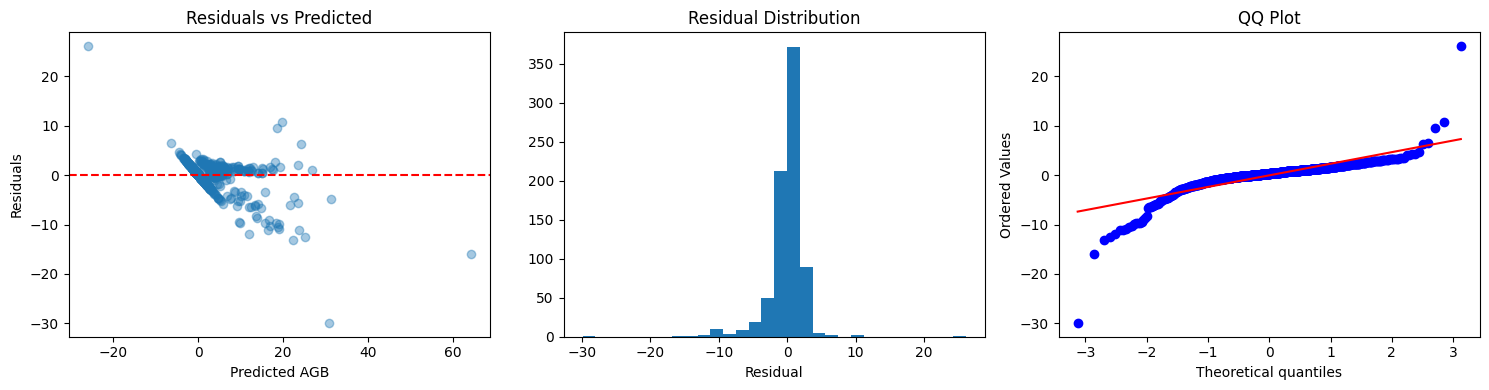

In [28]:
y_pred    = linear_reg_experiments[lin_best_label]["y_pred"]
residuals = linear_reg_experiments[lin_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# RANDOM FOREST.

In [29]:
random_forest_experiments={}

## RandomForest model with just structural variables excluding plot_id variable.

In [30]:
from model_functions import *

label_1 = "Structural variables without plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_1]["X_data"],
                            y,
                            groups,
                            label_1)
results["X_data"] = linear_reg_experiments["LIN: " + label_1]["X_data"].copy()

random_forest_experiments["RF: " +label_1] = results

show_importances(results)

EXPERIMENT  : Structural variables without plot_id
Test R²     : 0.8817
Test RMSE   : 1.59 kg
Train R²    : 0.9676
Train RMSE  : 3.34 kg
Num Features: 5

 Cross-validation ---
CV R² mean: 0.8718
CV R² std : 0.1431
CV scores : [0.916 0.84  0.977 0.943 0.824 0.939 0.871 0.949 0.987 0.472]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4076
Grouped CV R² std : 0.6956
Grouped CV scores : [ 0.766  0.412  0.902 -1.09   0.698  0.772  0.741  0.877  0.816 -0.819]

Top 4 feature importances:
  diameter                                      0.7275  ████████████████████████████████████
  height                                        0.2222  ███████████
  MSI                                           0.0340  █
  species_Avicennia germinans                   0.0112  


## RandomForest model with just structural variables including plot_id variable.

In [31]:
label_2 = "Structural variables + plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_2]["X_data"],
                            y,
                            groups,
                            label_2)
results["X_data"] = linear_reg_experiments["LIN: " + label_2]["X_data"].copy()

random_forest_experiments["RF: " +label_2] = results

show_importances(results)

EXPERIMENT  : Structural variables + plot_id
Test R²     : 0.8628
Test RMSE   : 1.71 kg
Train R²    : 0.9465
Train RMSE  : 4.29 kg
Num Features: 7

 Cross-validation ---
CV R² mean: 0.8388
CV R² std : 0.1601
CV scores : [0.826 0.769 0.965 0.921 0.809 0.927 0.863 0.93  0.976 0.401]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4112
Grouped CV R² std : 0.6826
Grouped CV scores : [ 0.744  0.429  0.897 -1.05   0.701  0.775  0.746  0.87   0.805 -0.807]

Top 4 feature importances:
  diameter                                      0.6866  ██████████████████████████████████
  height                                        0.2360  ███████████
  MSI                                           0.0378  █
  plot_id_Channel Caye_1                        0.0125  


## RandomForest model with just structural variables along with interaction terms.

In [32]:
label_3 = 'Structural variables + interaction terms'
results = randomForest_groups(linear_reg_experiments["LIN: " + label_3]["X_data"],
                            y,
                            groups,
                            label_3)
results["X_data"] = linear_reg_experiments["LIN: " + label_3]["X_data"].copy()
random_forest_experiments["RF: " +label_3] = results

show_importances(results)

EXPERIMENT  : Structural variables + interaction terms
Test R²     : 0.9332
Test RMSE   : 1.19 kg
Train R²    : 0.9747
Train RMSE  : 2.95 kg
Num Features: 10

 Cross-validation ---
CV R² mean: 0.9040
CV R² std : 0.0800
CV scores : [0.926 0.869 0.986 0.962 0.85  0.926 0.859 0.956 0.992 0.714]

Grouped Cross-validation ---
Grouped CV R² mean: 0.8052
Grouped CV R² std : 0.1630
Grouped CV scores : [0.902 0.619 0.941 0.572 0.892 0.93  0.874 0.897 0.93  0.494]

Top 4 feature importances:
  diameter                                      0.4078  ████████████████████
  diameter_x_height                             0.2200  ██████████
  diameter_x_species_Avicennia germinans        0.2001  ██████████
  height                                        0.0705  ███


## RandomForest model with just EMIT Bands.

In [33]:
label_4 = "EMIT bands only"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_4]["X_data"],
                            y,
                            groups,
                            label_4)
results["X_data"] = linear_reg_experiments["LIN: " + label_4]["X_data"].copy()
random_forest_experiments["RF: " +label_4] = results

show_importances(results)

EXPERIMENT  : EMIT bands only
Test R²     : 0.1684
Test RMSE   : 4.21 kg
Train R²    : 0.2243
Train RMSE  : 16.35 kg
Num Features: 157

 Cross-validation ---
CV R² mean: 0.0715
CV R² std : 0.1708
CV scores : [ 0.059 -0.03   0.455 -0.031 -0.082  0.038 -0.195  0.169  0.181  0.151]

Grouped Cross-validation ---
Grouped CV R² mean: -0.0326
Grouped CV R² std : 0.5050
Grouped CV scores : [-0.032  0.143  0.464  0.101  0.176  0.069 -1.502  0.074  0.09   0.091]

Top 4 feature importances:
  EMIT_R723                                     0.0356  █
  EMIT_R597                                     0.0348  █
  EMIT_R559                                     0.0345  █
  EMIT_R761                                     0.0319  █


## RandomForest model with all of the variables excluding plot_id variable.

In [34]:
label_5 = "All variables (structural + EMIT) without plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_5]["X_data"],
                            y,
                            groups,
                            label_5)
results["X_data"] = linear_reg_experiments["LIN: " + label_5]["X_data"].copy()
random_forest_experiments["RF: " +label_5] = results

show_importances(results)

EXPERIMENT  : All variables (structural + EMIT) without plot_id
Test R²     : 0.9260
Test RMSE   : 1.26 kg
Train R²    : 0.9268
Train RMSE  : 5.02 kg
Num Features: 162

 Cross-validation ---
CV R² mean: 0.7414
CV R² std : 0.1807
CV scores : [0.792 0.741 0.909 0.26  0.64  0.751 0.736 0.798 0.936 0.853]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4812
Grouped CV R² std : 0.5693
Grouped CV scores : [ 0.767  0.479  0.919 -0.732  0.726  0.782  0.683  0.888  0.829 -0.528]

Top 4 feature importances:
  diameter                                      0.5579  ███████████████████████████
  height                                        0.2045  ██████████
  species_Avicennia germinans                   0.0157  
  EMIT_R597                                     0.0085  


## RandomForest model with all of the variables including plot_id variable.

In [35]:
label_6 = "All variables (structural + EMIT) + plot_id"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_6]["X_data"],
                            y,
                            groups,
                            label_6)
results["X_data"] = linear_reg_experiments["LIN: " + label_6]["X_data"].copy()
random_forest_experiments["RF: " +label_6] = results

show_importances(results)

EXPERIMENT  : All variables (structural + EMIT) + plot_id
Test R²     : 0.9279
Test RMSE   : 1.24 kg
Train R²    : 0.9073
Train RMSE  : 5.65 kg
Num Features: 164

 Cross-validation ---
CV R² mean: 0.7266
CV R² std : 0.1962
CV scores : [0.742 0.673 0.905 0.206 0.641 0.751 0.73  0.816 0.937 0.866]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4760
Grouped CV R² std : 0.5697
Grouped CV scores : [ 0.753  0.476  0.919 -0.741  0.725  0.782  0.683  0.881  0.813 -0.531]

Top 4 feature importances:
  diameter                                      0.5345  ██████████████████████████
  height                                        0.2045  ██████████
  species_Avicennia germinans                   0.0173  
  EMIT_R597                                     0.0093  


## RandomForest model with all of the variables along with interaction terms.

In [36]:
label_7 = "All variables (structural + EMIT) + interaction terms"
results = randomForest_groups(linear_reg_experiments["LIN: " + label_7]["X_data"],
                            y,
                            groups,
                            label_7)
results["X_data"] = linear_reg_experiments["LIN: " + label_7]["X_data"].copy()
random_forest_experiments["RF: " +label_7] = results

show_importances(results)

EXPERIMENT  : All variables (structural + EMIT) + interaction terms
Test R²     : 0.9217
Test RMSE   : 1.29 kg
Train R²    : 0.9404
Train RMSE  : 4.53 kg
Num Features: 167

 Cross-validation ---
CV R² mean: 0.7971
CV R² std : 0.1242
CV scores : [0.844 0.784 0.926 0.47  0.748 0.762 0.819 0.837 0.941 0.84 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.7979
Grouped CV R² std : 0.1536
Grouped CV scores : [0.91  0.664 0.945 0.651 0.896 0.941 0.626 0.886 0.936 0.524]

Top 4 feature importances:
  diameter                                      0.2465  ████████████
  diameter_x_species_Avicennia germinans        0.1940  █████████
  diameter_x_height                             0.1805  █████████
  height                                        0.0853  ████


## Pick the best RandomForest model.
Pick the model with the highest Cross-Validation R2 mean value.

### Summary of experiments so far.

In [37]:
tabulate_results(random_forest_experiments)

,Experiment,Test R²,Test RMSE,Train R²,Tr4ain RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std
0,RF: Structural variables + interaction terms,0.933200,1.190000,0.974700,2.950000,0.904000,0.080000,0.805200,0.163000
1,RF: All variables (structural + EMIT) + interaction terms,0.921700,1.290000,0.940400,4.530000,0.797100,0.124200,0.797900,0.153600
2,RF: All variables (structural + EMIT) without plot_id,0.926000,1.260000,0.926800,5.020000,0.741400,0.180700,0.481200,0.569300
3,RF: All variables (structural + EMIT) + plot_id,0.927900,1.240000,0.907300,5.650000,0.726600,0.196200,0.476000,0.569700
4,RF: Structural variables + plot_id,0.862800,1.710000,0.946500,4.290000,0.838800,0.160100,0.411200,0.682600
5,RF: Structural variables without plot_id,0.881700,1.590000,0.967600,3.340000,0.871800,0.143100,0.407600,0.695600
6,RF: EMIT bands only,0.168400,4.210000,0.224300,16.350000,0.071500,0.170800,-0.032600,0.505000


## SELECT BEST RANDOM FOREST MODEL

In [38]:
rf_best_label = select_best_model(random_forest_experiments)
rf_X_selected = random_forest_experiments[rf_best_label]["X_data"]

print("Random Forest best model")
print(f"Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"CV Scores  : {random_forest_experiments[rf_best_label]["cv_scores"]}")

['RF: Structural variables + interaction terms']
Random Forest best model
Test R2    : 0.9331601926826896
CV R2 mean : 0.9039866396630934
CV Scores  : [0.92643871 0.86858586 0.98605969 0.96231635 0.84967462 0.92577466
 0.85907036 0.95647393 0.99169434 0.71377788]


In [39]:
show_importances(random_forest_experiments[rf_best_label])


Top 4 feature importances:
  diameter                                      0.4078  ████████████████████
  diameter_x_height                             0.2200  ██████████
  diameter_x_species_Avicennia germinans        0.2001  ██████████
  height                                        0.0705  ███


## Analysis

**R2 vs CV R2 mean**  
| Data type | Group CV | std |
| :--- | :----: | ---: |
|All variables (structural + EMIT) without plot_id | 0.4538 |   0.5260|
|Structural + interactions | 0.7782 | 0.2244|

All + EMIT is 0.33 points worse in generalization and 2.3 times more variable. This means:
 - On average it explains 45% of variance on unseen plots versus 78% for structural + interactions
 - Its performance swings wildly depending on which plots are held out
 - Some folds produce negative R² (-0.775, -0.220) meaning it actively fails on certain plot types
 - The tiny 0.006 test R² advantage for All + EMIT is not worth the massive generalization penalty.

**Feature importance**  
 - Diameter alone explains 38.59% of AGB variance  
 - Interaction term "diameter_x_species_Avicennia germinans" explains 20.64% of AGB variance
 - Interaction term "diameter_x_height" explains 18.63% of AGB variance

**NOTE:** The importance of **height** has dropped. But this is not because **height** is insignificant. It is because of the *importance splitting* with the interaction term **diameter_x_species_Avicennia germinans**.

The above two variables together account for 77.5% of the model's explanatory power.  

### Residual analysis

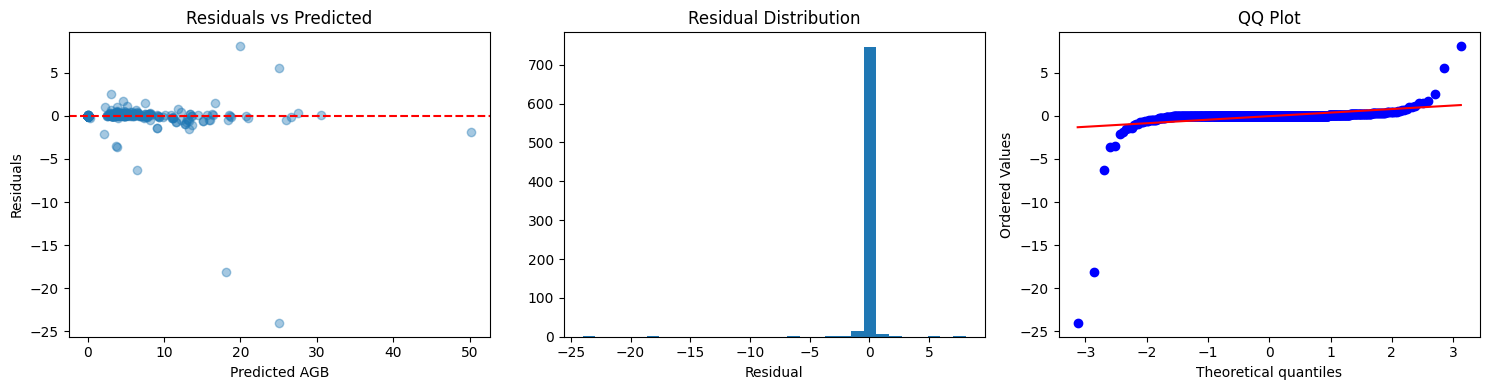

In [40]:
y_pred    = random_forest_experiments[rf_best_label]["y_pred"]
residuals = random_forest_experiments[rf_best_label]["residuals"]

residual_analysis(y_pred, residuals)

# EMIT PCA DATA

In [52]:
EMIT_PCA_TRAIN_CSV = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TRAIN.csv"
EMIT_PCA_TEST_CSV  = "../../DATA/AGB_DATA/Merged_Data/EMIT_AGB/PCA/AGB_EMIT_PCA_TEST.csv"

In [41]:
emit_pca_train_df = pd.read_csv(EMIT_PCA_TRAIN_CSV)
emit_pca_test_df  = pd.read_csv(EMIT_PCA_TEST_CSV)

In [42]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    #'plot_id',             # metadata
    'dataset',             # metadata
    'EMIT_selected_date',  # metadata
    'EMIT_granule',        # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
]

# Drop raw EMIT bands — keep only PCA components
emit_raw_cols = [c for c in emit_pca_train_df.columns if re.match(r'^EMIT_R\d+', c)]

# Training features and target
X_train = emit_pca_train_df.drop(columns=non_feature_cols + emit_raw_cols)
y_train = emit_pca_train_df['plant_AGB_kg']

# Test features and target
X_test  = emit_pca_test_df.drop(columns=non_feature_cols + emit_raw_cols)
y_test  = emit_pca_test_df['plant_AGB_kg']

print(f"Features : {len(X_train.columns)}")
print(f"Columns  : {list(X_train.columns)}")

# Preserve original plot_id for grouping.
groups = pd.concat([X_train, X_test], axis=0)['plot_id']

X_train = X_train.drop(columns=['plot_id'])
X_test = X_test.drop(columns=['plot_id'])

Features : 16
Columns  : ['plot_id', 'diameter', 'height', 'species', 'NDVI', 'NDRE1', 'NDRE2', 'NDRE3', 'NBR', 'MSI', 'EVI', 'CIrededge', 'EMIT_PC1', 'EMIT_PC2', 'EMIT_PC3', 'EMIT_PC4']


In [43]:
# One-hot encode species
X_train = pd.get_dummies(X_train, columns=['species'], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['species'], dtype=int)

# Align columns — test may have different species columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [44]:
# Add interaction terms
species_cols = [c for c in X_train.columns if c.startswith('species_')]

for col in species_cols:
    X_train[f'diameter_x_{col}'] = X_train['diameter'] * X_train[col]
    X_test[f'diameter_x_{col}']  = X_test['diameter']  * X_test[col]
    X_train[f'height_x_{col}']   = X_train['height']   * X_train[col]
    X_test[f'height_x_{col}']    = X_test['height']    * X_test[col]

X_train['diameter_x_height'] = X_train['diameter'] * X_train['height']
X_test['diameter_x_height']  = X_test['diameter']  * X_test['height']

In [45]:
pca_results = {}

## LINEAR REGRESSION ON PCA

In [46]:
label = "Structural variables + Interaction terms + PCA components"
result = linear_reg_ver2(X_train, X_test, y_train, y_test, groups, label)
pca_results["PCA: " + label] = result


--- Structural variables + Interaction terms + PCA components ---
Test R²     : 0.5094
Test RMSE   : 3.23 kg
Train R²    : -37314218.0447
Train RMSE  : 113431.68 kg
Num Features: 24

 Cross-validation ---
CV R² mean: 0.4100
CV R² std : 0.5450
CV scores : [ 0.907  0.899  0.858  0.491 -0.648  0.854  0.333 -0.146  0.826 -0.276]

Grouped Cross-validation ---
Grouped CV R² mean: 0.7717
Grouped CV R² std : 0.2420
Grouped CV scores : [0.89  0.889 0.622 0.807 0.947 0.937 0.102 0.821 0.773 0.93 ]


### ANALYSIS

In [47]:
print(f"Previous best Linear regression: {lin_best_label}")
print(f"Test R2         : {linear_reg_experiments[lin_best_label]["test_r2"]}")
print(f"CV R2 mean      : {linear_reg_experiments[lin_best_label]["cv_r2_mean"]}")
print(f"CV R2 std       : {linear_reg_experiments[lin_best_label]["cv_r2_std"]}")
print(f"Group CV R2 mean: {linear_reg_experiments[lin_best_label]["group_cv_r2_mean"]}")
print(f"Group CV R2 std : {linear_reg_experiments[lin_best_label]["group_cv_r2_std"]}")

Previous best Linear regression: LIN: Structural variables + interaction terms
Test R2         : 0.6338916057332096
CV R2 mean      : 0.4218365757504955
CV R2 std       : 0.5095624107010742
Group CV R2 mean: 0.8051787073461352
Group CV R2 std : 0.1630354143598664


**Compare with previous best:**
| Data type | Test R^2 | Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: |
|Structural + interactions| 0.6339| 0.7781| 0.2244|
|Structural + interactions + PCA| 0.5094| 0.7717| 0.2420|

**REVISIT**

**Group CV improved from 0.7782 to 0.8065**  
Adding 4 PCA components to the structural + interaction model improved honest generalization by 0.028 points.  
This is modest but consistent — the PCA components are adding a small amount of genuine signal beyond structural variables alone.

**Group CV std improved from 0.2244 to 0.1756**  
The model is more stable across fold combinations.  
This is actually more meaningful than the mean improvement — it means the PCA components help the model generalize more consistently across different plot types, not just on average.

**Test R² dropped from 0.6339 to 0.5094**  
The 12 held-out test plots happen to be harder to predict with PCA components included.  
This is a single split artifact — the group CV is the reliable number here.


**Minimum Fold Score (Minimum of CV scores)**  
Previous best minimum fold : 0.158  
PCA model minimum fold     : 0.418   
 - CV scores: [0.905, 0.642, 0.943, 0.595, 0.896, 0.937, 0.894, 0.902, 0.932, 0.418]

The worst-case fold improved substantially.  
The PCA components are helping the model handle the previously problematic plot combinations — the ones that collapsed to 0.158 in the structural-only model.

## RANDOM FOREST ON PCA

In [48]:
label_rf = "All variables (structural + EMIT) + PCA"
result = randomForest_ver2(X_train, X_test, y_train, y_test, groups, label_rf)
show_importances(results)

pca_results["PCA: " + label_rf] = result

EXPERIMENT  : All variables (structural + EMIT) + PCA
Test R²     : 0.8991
Test RMSE   : 1.47 kg
Train R²    : 0.9616
Train RMSE  : 3.64 kg
Num Features: 24

 Cross-validation ---
CV R² mean: 0.8644
CV R² std : 0.0908
CV scores : [0.887 0.83  0.973 0.891 0.745 0.839 0.904 0.939 0.962 0.673]

Grouped Cross-validation ---
Grouped CV R² mean: 0.7717
Grouped CV R² std : 0.2420
Grouped CV scores : [0.89  0.889 0.622 0.807 0.947 0.937 0.102 0.821 0.773 0.93 ]

Top 4 feature importances:
  diameter                                      0.2465  ████████████
  diameter_x_species_Avicennia germinans        0.1940  █████████
  diameter_x_height                             0.1805  █████████
  height                                        0.0853  ████


In [49]:
tabulate_results(pca_results)

,Experiment,Test R²,Test RMSE,Train R²,Tr4ain RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std
0,PCA: Structural variables + Interaction terms + PCA components,0.509400,3.230000,-37314218.044700,113431.680000,0.410000,0.545000,0.771700,0.242000
1,PCA: All variables (structural + EMIT) + PCA,0.899100,1.470000,0.961600,3.640000,0.864400,0.090800,0.771700,0.242000


### Analysis

**Compare with previous best**

In [50]:
print(f"Previous best Random Forest model: {rf_best_label}")
print(f"RF: Test R2    : {random_forest_experiments[rf_best_label]["test_r2"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_mean"]}")
print(f"RF: CV R2 mean : {random_forest_experiments[rf_best_label]["cv_r2_std"]}")
print(f"RF: Group CV R2 mean: {random_forest_experiments[rf_best_label]["group_cv_r2_mean"]}")
print(f"RF: Group CV R2 std : {random_forest_experiments[rf_best_label]["group_cv_r2_std"]}")

Previous best Random Forest model: RF: Structural variables + interaction terms
RF: Test R2    : 0.9331601926826896
RF: CV R2 mean : 0.9039866396630934
RF: CV R2 mean : 0.07997784966284494
RF: Group CV R2 mean: 0.8051787073461352
RF: Group CV R2 std : 0.1630354143598664


| Data type | Test R^2 | CV R^2 Mean | CV R^2 Std| Group CV R^2 Mean | Group CV R^2 std |
| :--- | :----: | ---: | ---: | ---: | ---: |
|RF: Structural + interactions| 0.9145| 0.8937| 0.1004| 0.9532| 0.0429|
|RF: All + EMIT + PCA| 0.8991| 0.8644| 0.0908| 0.9286| 0.0507|

Structural + interactions is the better model on every metric.
 - Test R² is higher (0.9145 vs 0.8991)  
 - CV mean is higher (0.8937 vs 0.8644)  
 - Group CV mean is higher (0.9532 vs 0.9286) <- Important  
 - Group Std is lower (0.0429 vs 0.0507)

It looks like adding EMIT bands data in any form (direct data or PCA components) to the structural variables is hurting the performance.

**Let us look at the Feature Importances.**  
**Random Forest (Data = Structural variables + Interaction terms):**  
| Feature | Importance |
| :--- | :----: |
  |diameter|                  0.3859 | 
  |diameter_x_Avicennia|      0.2064 |
  |diameter_x_height|         0.1863 | 
  |height|                    0.0803 | 

**Random Forest (Data = Structural variables + EMIT + PCA components):**  
| Feature | Importance |
| :--- | :----: |
  |diameter |                 0.2425  |
  |diameter_x_Avicennia|      0.1877  |
  |diameter_x_height|         0.1822  |
  |height|                    0.0930  |

It appears that adding PCA components is diluting the importance of structural variables — diameter drops from 0.39 to 0.24.  
The model is spreading its attention across more features without gaining predictive power.  
The PCA components are absorbing importance that was previously concentrated in the dominant structural signal.

# FINAL ANALYSIS

**Test R²**  
 — based on one specific split of 12 plots.  
 - A different random seed gives a different number.  
 - Not reproducible or representative.

**CV R² mean**  
 — based on random KFold that splits trees without respecting plot boundaries.  
 - Pseudo-replication inflates it.

It tests on trees, not plots.  
Trees from the same plot appear in both training and test within the same fold.  
The model has already seen the plot — it is not truly unseen.  
The question being answered is "how well does the model predict trees from plots it has partially seen".

**Group CV R² mean**
 — based on 10 folds where entire plots are held out.  
 - Every plot gets to be a test plot exactly once.
 - No pseudo-replication. 
 - Reproducible.
 - This is the number that can answer the question — how well does the model predict AGB for plots it has never seen?

In [51]:
total_experiments = {**linear_reg_experiments, **random_forest_experiments, **pca_results}
tabulate_results(total_experiments)

,Experiment,Test R²,Test RMSE,Train R²,Tr4ain RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std
0,LIN: Structural variables + interaction terms,0.633900,2.790000,-31571127.250000,104337.940000,0.421800,0.509600,0.805200,0.163000
1,RF: Structural variables + interaction terms,0.933200,1.190000,0.974700,2.950000,0.904000,0.080000,0.805200,0.163000
2,LIN: All variables (structural + EMIT) + interaction terms,0.628000,2.810000,-46095033.036800,126073.630000,0.398000,0.571600,0.797900,0.153600
3,RF: All variables (structural + EMIT) + interaction terms,0.921700,1.290000,0.940400,4.530000,0.797100,0.124200,0.797900,0.153600
4,PCA: Structural variables + Interaction terms + PCA components,0.509400,3.230000,-37314218.044700,113431.680000,0.410000,0.545000,0.771700,0.242000
5,PCA: All variables (structural + EMIT) + PCA,0.899100,1.470000,0.961600,3.640000,0.864400,0.090800,0.771700,0.242000
6,LIN: All variables (structural + EMIT) without plot_id,-0.276900,5.220000,-10071.951500,1863.700000,-0.584900,1.347900,0.481200,0.569300
7,RF: All variables (structural + EMIT) without plot_id,0.926000,1.260000,0.926800,5.020000,0.741400,0.180700,0.481200,0.569300
8,LIN: All variables (structural + EMIT) + plot_id,-0.274000,5.210000,-9949.213000,1852.310000,-0.587200,1.349700,0.476000,0.569700
9,RF: All variables (structural + EMIT) + plot_id,0.927900,1.240000,0.907300,5.650000,0.726600,0.196200,0.476000,0.569700


**NOTE:**  
Andre's global model achieved R²=0.36 with 524 grid cells and 5 climate variables.  

**Structural only — R² = 0.84, 6 features**  
Diameter, height, species, wood density alone explain 84% of variance.  

**EMIT bands only — R² = 0.25, 157 features**  
 - Spectral data alone is a weak predictor of individual tree AGB.  
 - This makes sense — a single 60m EMIT pixel captures the canopy of many trees mixed together, not one individual tree.
 - The spectral signal is a stand-level measurement being used to predict a tree-level target.  
 - The resolution mismatch is the fundamental problem here.

**plot_id paradox**  
 - Adding plot_id improves EMIT-only performance but hurts or does nothing when structural variables are present.
 - This confirms structural variables already capture what plot_id was proxying for.

**FINALLY**  
 - The above confirms that  diameter, height, and species are the dominant drivers of individual tree AGB.
 - The AGB values in the Belige dataset is computed mathematically using allometric equations. So it is anticipated that the structural parameters like Diameter, height, will be able to explain majority of the AGB variance.

**https://onlinelibrary.wiley.com/doi/10.1002/ldr.70594?af=R**
A study of 109 mangrove trees across eight species in Timor-Leste found very strong positive correlations between DBH and biomass variables (r = 0.963–0.971), indicating that tree diameter represents a reliable predictor of biomass and carbon storage. 

**https://pmc.ncbi.nlm.nih.gov/articles/PMC12425185/**
A study using 302 destructively sampled mangrove trees found that the single parameter with the strongest predictive ability in most studies is diameter at breast height (DBH), and that DBH explains a lot of variability in other tree metrics such as height or aboveground biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0304377007001829**
Komiyama et al. (2008) in their widely cited review of mangrove allometry state that trunk diameter of a tree is highly correlated with trunk weight, and that since tree diameter is easy to measure but tree weight is much more difficult to determine, this gives a relatively easy way to estimate biomass. 

**https://www.sciencedirect.com/science/article/abs/pii/S0272771420307022**
Chave et al. (2005) reported that allometric equations with total tree height yielded less biased estimates of AGB, though tree height has often been ignored in carbon-accounting programs because measuring tree height accurately is difficult in mangrove forests. 